#Implement an End to End CNN Model for Image Classification Task.

In [2]:
train_dir = "/content/drive/MyDrive/AIandML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AIandML/FruitinAmazon/test"

Task 1: Data Understanding and Visualization

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

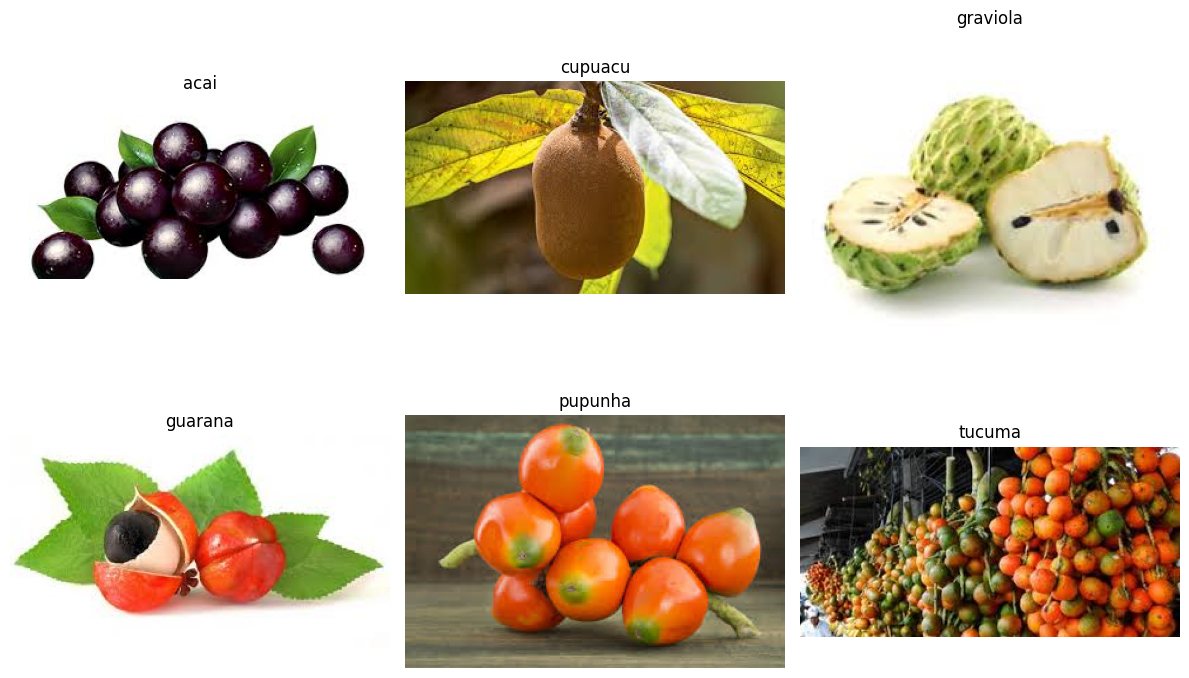

In [3]:
import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

sample_images = []
sample_labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        if len(image_files) > 0:
            img_name = random.choice(image_files)
            img_path = os.path.join(class_path, img_name)
            sample_images.append(img_path)
            sample_labels.append(cls)

num_images = len(sample_images)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(4 * cols, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(sample_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

The dataset is organized into multiple fruit categories, each placed in its own class folder. The sample images highlight noticeable variations in color, texture and shape among the fruits, though certain classes may still appear visually similar. Additionally, differences in backgrounds, lighting conditions and fruit orientations are present, which can increase the complexity of the classification task.

2. Check for Corrupted Image.

In [4]:
from PIL import Image

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            image_path = os.path.join(class_path, file_name)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in keras

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

img_height = 128
img_width = 128
batch_size = 16
seed = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    label_mode="int"
)

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Found 30 files belonging to 6 classes.


Task 3: Implement a CNN with

In [6]:
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.0944 - loss: 2.1366
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 394ms/step - accuracy: 0.0972 - loss: 2.0926 - val_accuracy: 0.1667 - val_loss: 1.8934
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.2313 - loss: 1.7277
Epoch 2: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.2500 - loss: 1.6975 - val_accuracy: 0.1111 - val_loss: 1.8793
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3118 - loss: 1.5896
Epoch 3: val_accuracy improved from 0.16667 to 0.27778, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 0.4028 - loss: 1.5516 - val_accuracy: 0.2778 - val_loss: 1.7871
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.4951 - loss: 1.3848
Epoch 4: val_accuracy improved from 0.27778 to 0.33333, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - accuracy: 0.5278 - loss: 1.3477 - val_accuracy: 0.3333 - val_loss: 1.7504
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.6722 - loss: 1.0437
Epoch 5: val_accuracy improved from 0.33333 to 0.44444, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.6944 - loss: 1.0268 - val_accuracy: 0.4444 - val_loss: 1.5896
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.7622 - loss: 0.8060
Epoch 6: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.7639 - loss: 0.7853 - val_accuracy: 0.4444 - val_loss: 2.1737
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7028 - loss: 0.7024
Epoch 7: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.7222 - loss: 0.7013 - val_accuracy: 0.3889 - val_loss: 1.3769
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8809 - loss: 0.4403
Epoch 8: val_accuracy improved from 0.44444 to 0.50000, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step - accuracy: 0.8889 - loss: 0.4160 - val_accuracy: 0.5000 - val_loss: 1.6661
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9840 - loss: 0.2447
Epoch 9: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - accuracy: 0.9722 - loss: 0.2679 - val_accuracy: 0.5000 - val_loss: 1.4085
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.9882 - loss: 0.1223
Epoch 10: val_accuracy improved from 0.50000 to 0.61111, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.9722 - loss: 0.1397 - val_accuracy: 0.6111 - val_loss: 1.1728
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 1.0000 - loss: 0.0894
Epoch 11: val_accuracy did not improve from 0.61111
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 1.0000 - loss: 0.0828 - val_accuracy: 0.5000 - val_loss: 1.8169
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 1.0000 - loss: 0.0474
Epoch 12: val_accuracy did not improve from 0.61111
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step - accuracy: 1.0000 - loss: 0.0499 - val_accuracy: 0.5000 - val_loss: 1.9370
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.0253
Epoch 13: val_accuracy improved from 0.61111 to 0.66667, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 1.0000 - loss: 0.0232 - val_accuracy: 0.6667 - val_loss: 1.3325
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 1.0000 - loss: 0.0153
Epoch 14: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 1.0000 - loss: 0.0207 - val_accuracy: 0.6111 - val_loss: 1.3265
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 1.0000 - loss: 0.0131
Epoch 15: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.5556 - val_loss: 1.6249
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 1.0000 - loss: 0.0135
Epoch 16: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.5556 - val_loss: 1.8609
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 1.0000 - los

Accuracy Graph

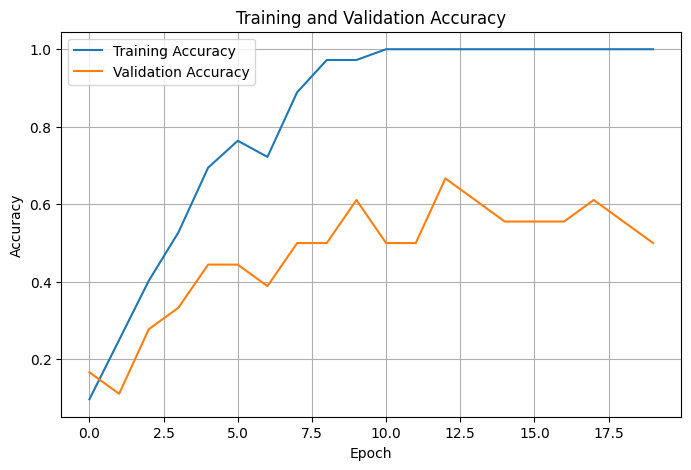

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Loss Graph

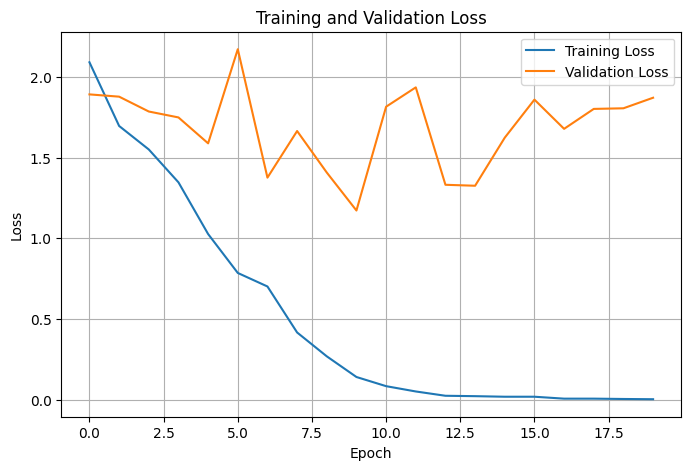

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Task 5: Evaluate the Model

In [10]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.8000 - loss: 0.8050
Test Loss: 0.8050417304039001
Test Accuracy: 0.800000011920929


Task 6: Save and Load the Model

In [11]:
model.save("/content/drive/MyDrive/AIandML/FruitinAmazon/fruit_cnn_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [12]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/AIandML/FruitinAmazon/fruit_cnn_model.h5")

In [13]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8000 - loss: 0.8050
Loaded Model Test Loss: 0.8050417304039001
Loaded Model Test Accuracy: 0.800000011920929


Task 7: Predictions and Classification Report

In [14]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.80        30
weighted avg       0.88      0.80      0.80        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step


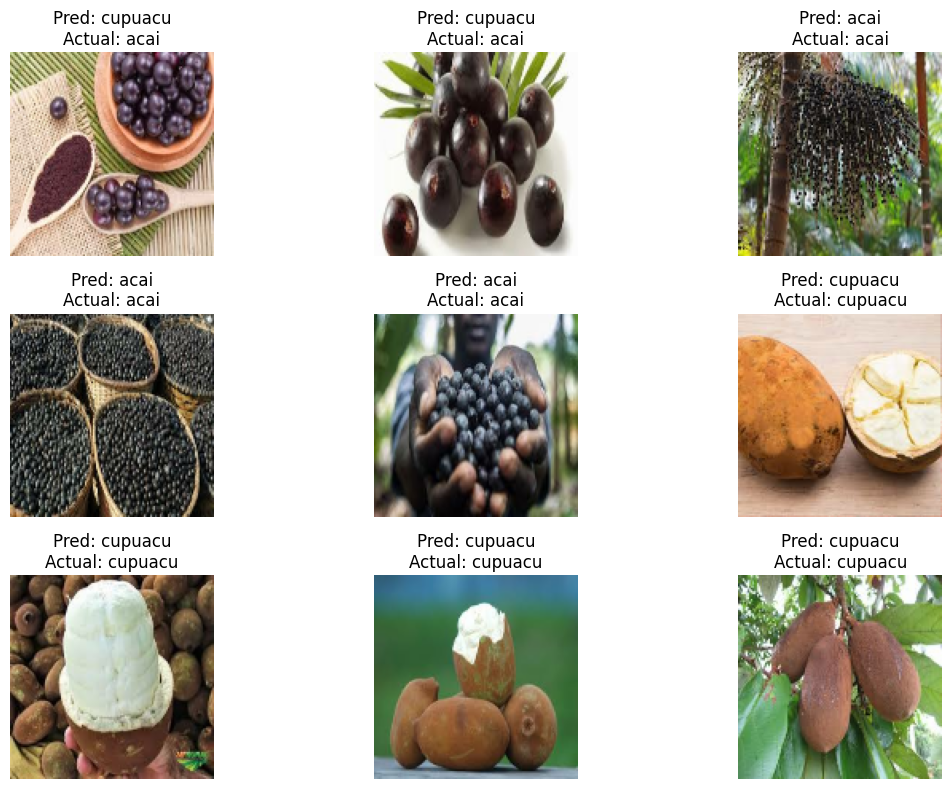

In [15]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[predicted_labels[i]]}\nActual: {class_names[labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()